In [1]:
import logging
logging.basicConfig(level=logging.WARNING)
root_logger = logging.getLogger()
root_logger.setLevel(logging.WARNING)
for name in ("transformers", "tokenizers", "torch"):
    logging.getLogger(name).setLevel(logging.WARNING)

import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm import LSTM as LSTM1
from models.lstm_proj_diff import LSTM as LSTM2
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [2]:
np.exp(1.59)

np.float64(4.903748928326623)

In [18]:
df_eval = pd.read_parquet("data/tokenized_test.parquet")
# df_train = pd.read_parquet("data/tokenized_train.parquet").sample(n=100, random_state=42).reset_index(drop=True)

In [19]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_50000.json")

In [21]:
dataset_eval = TranslateDataset(
    tokens_src=df_eval['en_tokens_50000'].tolist(),
    tokens_tgt=df_eval['pt_tokens_50000'].tolist(),
    invert_src=False,
    max_len=30
)

dataloader_eval = DataLoader(dataset_eval, batch_size=64, shuffle=False)

In [22]:
MODELS_TRY = [
    LSTM2
]

In [23]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file.split(".")[0].replace('model_', '')
        # keep only models with version >= 47
        try:
            ver = int(model_name.lstrip('v')) if model_name.startswith('v') else None
        except ValueError:
            ver = None
        if ver is None or ver < 47:
            continue
        print(f'Lendo {model_name}')
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        for MODEL_TRY in MODELS_TRY:
            try:
                model = MODEL_TRY(embedding_dim=model_config["embedding_dim"],
                            encoder_bidirectional=model_config["encoder_bidirectional"],
                            encoder_hidden_dim=model_config["encoder_hidden_dim"],
                            encoder_num_layers=model_config["encoder_num_layers"],
                            decoder_hidden_dim=model_config["decoder_hidden_dim"],
                            decoder_num_layers=model_config["decoder_num_layers"],
                            encoder_dropout=model_config["encoder_dropout"],
                            decoder_dropout=model_config["decoder_dropout"],
                            vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 10000, 
                            pad_idx=0)
                model.load_state_dict(torch.load(model_path))
                model.to("cuda" if torch.cuda.is_available() else "cpu")
                model.eval()
                models[model_name] = model
                break
            except RuntimeError as e:
                print(str(e))
                continue

Lendo v47
Lendo v48
Lendo v49
Lendo v50
Lendo v51
Lendo v52
Lendo v53


In [24]:
print(models.keys())

dict_keys(['v47', 'v48', 'v49', 'v50', 'v51', 'v52', 'v53'])


In [26]:
from utils.metrics import compute_bleu, compute_rouge
from torch.nn.utils.rnn import pad_sequence

metrics_by_model = {}
batch_size = 256

for model_name, model in models.items():

    print(f"Model: {model_name}")

    decoded_outputs = []
    reference_texts = []

    device = next(model.parameters()).device

    # Iterar manualmente pelo dataset e aplicar padding por batch
    n = len(dataset_eval)
    for start in tqdm(range(0, n, batch_size)):
        batch_items = [dataset_eval[i] for i in range(start, min(start + batch_size, n))]
        srcs = [item[0] for item in batch_items]
        tgts = [item[1] for item in batch_items]

        srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=0).to(device)
        tgts_padded = pad_sequence(tgts, batch_first=True, padding_value=0).to(device)

        tgt_tokens = tgts_padded[:, 1:]  # Remove o token de início

        # Decode ground-truth references (skip special tokens for metrics)
        reference_texts.extend(
            tokenizer.decode_batch(
                tgt_tokens.cpu().tolist(),
                skip_special_tokens=True
            )
        )

        with torch.no_grad():
            outputs = model.predict(
                src=srcs_padded,
                bos_token_id=5,
                eos_token_id=6,
                max_len=30,
            )

        # Decode predictions (skip special tokens for metrics)
        decoded_outputs.extend(
            tokenizer.decode_batch(
                outputs.cpu().tolist(),
                skip_special_tokens=True
            )
        )

    df_eval[f'{model_name}_pred'] = decoded_outputs

    # Compute metrics using utils/metrics
    try:
        bleu_res = compute_bleu(reference_texts, decoded_outputs)
    except Exception as e:
        bleu_res = {"error": str(e)}
    try:
        rouge_res = compute_rouge(reference_texts, decoded_outputs)
    except Exception as e:
        rouge_res = {"error": str(e)}

    metrics_by_model[model_name] = {"bleu": bleu_res, "rouge": rouge_res}
    print('BLEU:', bleu_res)
    print('ROUGE:', rouge_res)


Model: v47


100%|██████████| 3193/3193 [02:57<00:00, 17.99it/s]
INFO:absl:Using default tokenizer.


BLEU: {'bleu': 3.306515401460526}
ROUGE: {'rouge1': {'precision': 0.2190197456100319, 'recall': 0.29419822219564745, 'fmeasure': 0.2484497943650542}, 'rouge2': {'precision': 0.0768454823729003, 'recall': 0.10537332419543247, 'fmeasure': 0.08776592688597626}, 'rougeL': {'precision': 0.2074634100335352, 'recall': 0.27920606177470175, 'fmeasure': 0.23550046612171477}}
Model: v48


100%|██████████| 3193/3193 [02:24<00:00, 22.10it/s]
INFO:absl:Using default tokenizer.


BLEU: {'bleu': 2.8730349611736665}
ROUGE: {'rouge1': {'precision': 0.2971432731151182, 'recall': 0.1957264405321038, 'fmeasure': 0.2313884879465229}, 'rouge2': {'precision': 0.11114743669433565, 'recall': 0.07057873025687984, 'fmeasure': 0.08424232249729963}, 'rougeL': {'precision': 0.28545789346700057, 'recall': 0.18875705425044242, 'fmeasure': 0.2227980571573645}}
Model: v49


...

BLEU: {'bleu': 0.39661664623447956}
ROUGE: {'rouge1': {'precision': 0.4290821809517313, 'recall': 0.15406741892590398, 'fmeasure': 0.22109910039987452}, 'rouge2': {'precision': 0.09353538767114085, 'recall': 0.028946012530285743, 'fmeasure': 0.0430275587780355}, 'rougeL': {'precision': 0.4186998898943119, 'recall': 0.14990710702972465, 'fmeasure': 0.21524456014287877}}
Model: v52


100%|██████████| 3193/3193 [01:38<00:00, 32.39it/s]
INFO:absl:Using default tokenizer.


BLEU: {'bleu': 2.509927419049619}
ROUGE: {'rouge1': {'precision': 0.5076609042556017, 'recall': 0.235195774992681, 'fmeasure': 0.31310261773984727}, 'rouge2': {'precision': 0.19765590520517184, 'recall': 0.0826117574291384, 'fmeasure': 0.11274458500696025}, 'rougeL': {'precision': 0.5004197702513882, 'recall': 0.23205961180963555, 'fmeasure': 0.3088176752926357}}
Model: v53


100%|██████████| 3193/3193 [02:24<00:00, 22.04it/s]
INFO:absl:Using default tokenizer.


BLEU: {'bleu': 3.0338380175209876}
ROUGE: {'rouge1': {'precision': 0.35859078651906395, 'recall': 0.20493862438484234, 'fmeasure': 0.25382486418091293}, 'rouge2': {'precision': 0.14445621805125905, 'recall': 0.07348640284549572, 'fmeasure': 0.09416007638951604}, 'rougeL': {'precision': 0.347969521990464, 'recall': 0.19904161266915074, 'fmeasure': 0.2464400119076856}}


In [27]:
import pandas as pd

# Converter dict de métricas para DataFrame (linhas = modelos)
df_metrics = pd.DataFrame.from_dict(metrics_by_model, orient='index')

# Helper seguro para navegar dicionários aninhados
def _safe_get(d, keys, default=None):
    try:
        v = d
        for k in keys:
            if not isinstance(v, dict):
                return default
            v = v.get(k)
        return v
    except Exception:
        return default

# Extrair BLEU (pode ser dict {'bleu': val} ou já um número em casos especiais)
df_metrics['bleu_score'] = df_metrics['bleu'].apply(lambda b: b.get('bleu') if isinstance(b, dict) and 'bleu' in b else (b if isinstance(b, (int, float)) else None))

# Extrair todas as subcolunas do ROUGE (rouge1, rouge2, rougeL)
for r in ['rouge1', 'rouge2', 'rougeL']:
    for m in ['precision', 'recall', 'fmeasure']:
        df_metrics[f'{r}_{m}'] = df_metrics['rouge'].apply(lambda x: _safe_get(x, [r, m]))

# Perplexity (já deve ser numérico) e limpeza básica
df_metrics['perplexity'] = df_metrics.get('perplexity').apply(lambda x: float(x) if x is not None else None) if 'perplexity' in df_metrics.columns else None

# Coluna auxiliar com recall do rouge2 para ordenação
df_metrics['rouge2_recall'] = df_metrics['rouge2_recall'] if 'rouge2_recall' in df_metrics.columns else df_metrics['rouge'].apply(lambda x: _safe_get(x, ['rouge2', 'recall']))

# Ordenar decrescentemente por recall do rouge2
df_metrics_sorted = df_metrics.sort_values('rouge2_recall', ascending=False)

df_metrics_sorted

,bleu,rouge,bleu_score,rouge1_precision,rouge1_recall,rouge1_fmeasure,rouge2_precision,rouge2_recall,rouge2_fmeasure,rougeL_precision,rougeL_recall,rougeL_fmeasure,perplexity
v50,{'bleu': 27.300111900904415},"{'rouge1': {'precision': 0.5910572596834202, '...",27.300112,0.591057,0.594106,0.588855,0.376018,0.380631,0.375670,0.581478,0.584517,0.579339,None
v47,{'bleu': 3.306515401460526},"{'rouge1': {'precision': 0.2190197456100319, '...",3.306515,0.219020,0.294198,0.248450,0.076845,0.105373,0.087766,0.207463,0.279206,0.235500,None
v52,{'bleu': 2.509927419049619},"{'rouge1': {'precision': 0.5076609042556017, '...",2.509927,0.507661,0.235196,0.313103,0.197656,0.082612,0.112745,0.500420,0.232060,0.308818,None
v53,{'bleu': 3.0338380175209876},"{'rouge1': {'precision': 0.35859078651906395, ...",3.033838,0.358591,0.204939,0.253825,0.144456,0.073486,0.094160,0.347970,0.199042,0.246440,None
v48,{'bleu': 2.8730349611736665},"{'rouge1': {'precision': 0.2971432731151182, '...",2.873035,0.297143,0.195726,0.231388,0.111147,0.070579,0.084242,0.285458,0.188757,0.222798,None
v51,{'bleu': 0.39661664623447956},"{'rouge1': {'precision': 0.4290821809517313, '...",0.396617,0.429082,0.154067,0.221099,0.093535,0.028946,0.043028,0.418700,0.149907,0.215245,None
v49,{'bleu': 0.595164950877583},"{'rouge1': {'precision': 0.3733987746456715, '...",0.595165,0.373399,0.116404,0.173192,0.075644,0.021959,0.033207,0.366382,0.113989,0.169643,None


In [38]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs = df_configs.loc[df_configs['name'].isin(models.keys())].sort_values(by='name', ascending=False)
df_configs = df_configs[['name'] + df_configs.columns.tolist()]
df_configs

,name,invert_src,embedding_dim,encoder_hidden_dim,decoder_hidden_dim,encoder_num_layers,decoder_num_layers,encoder_dropout,decoder_dropout,encoder_bidirectional,...,vocab_size,max_len,clip_grad,init_weight_method,init_bias_method,teacher_forcing,scheduler_sampling,teacher_forcing_ratio,max_steps_scheduler_sampling,curriculum_levels
43,v53,False,384,1024,1024,3,3,0.4,0.4,True,...,50000.0,30.0,NaN,xavier_uniform,zeros,True,True,1.0,500000.0,"[{'max_step': 125000, 'max_len': 10, 'batch_si..."
42,v52,False,384,1024,1024,3,3,0.4,0.4,True,...,50000.0,30.0,NaN,xavier_uniform,zeros,True,True,1.0,90000.0,"[{'max_step': 120000, 'max_len': 10, 'batch_si..."
41,v51,False,384,1024,1024,3,3,0.4,0.4,True,...,50000.0,30.0,1.5,xavier_uniform,zeros,True,True,1.0,300000.0,"[{'max_step': 120000, 'max_len': 10, 'batch_si..."
40,v50,False,384,1024,1024,3,3,0.4,0.4,True,...,50000.0,30.0,1.5,xavier_uniform,zeros,True,True,1.0,200000.0,"[{'max_step': 40000, 'max_len': 10, 'batch_siz..."
38,v49,False,384,1024,1024,3,3,0.4,0.4,True,...,50000.0,30.0,1.5,xavier_uniform,zeros,True,True,1.0,40000.0,"[{'max_step': 80000, 'max_len': 10, 'batch_siz..."
37,v48,False,384,1024,1024,3,3,0.4,0.4,True,...,50000.0,30.0,1.5,xavier_uniform,zeros,True,False,1.0,50000.0,"[{'max_step': 80000, 'max_len': 10, 'batch_siz..."
36,v47,False,384,1024,1024,3,3,0.4,0.4,True,...,50000.0,30.0,1.5,xavier_uniform,zeros,True,False,1.0,50000.0,"[{'max_step': 500000, 'max_len': 30, 'batch_si..."


In [39]:
df_configs.to_dict(orient='records')

/tmp/ipykernel_7761/2668726291.py:1: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  df_configs.to_dict(orient='records')


[{'name': 'v53',
  'invert_src': False,
  'embedding_dim': 384,
  'encoder_hidden_dim': 1024,
  'decoder_hidden_dim': 1024,
  'encoder_num_layers': 3,
  'decoder_num_layers': 3,
  'encoder_dropout': 0.4,
  'decoder_dropout': 0.4,
  'encoder_bidirectional': True,
  'batch_size': 256,
  'accum_steps': 1,
  'log_steps': 250,
  'save_steps': 1000,
  'eval_steps': 500,
  'device': 'cuda',
  'desc': 'Atrasando curriculo para 120 mil e removendo clip de gradiente',
  'early_stop_patience': 100,
  'early_stop_min_delta': 0.0,
  'warmup_steps': 1000.0,
  'max_steps': 500000.0,
  'learning_rate': 0.0001,
  'vocab_size': 50000.0,
  'max_len': 30.0,
  'clip_grad': nan,
  'init_weight_method': 'xavier_uniform',
  'init_bias_method': 'zeros',
  'teacher_forcing': True,
  'scheduler_sampling': True,
  'teacher_forcing_ratio': 1.0,
  'max_steps_scheduler_sampling': 500000.0,
  'curriculum_levels': [{'max_step': 125000,
    'max_len': 10,
    'batch_size': 1024,
    'accum_steps': 1},
   {'max_step': 5

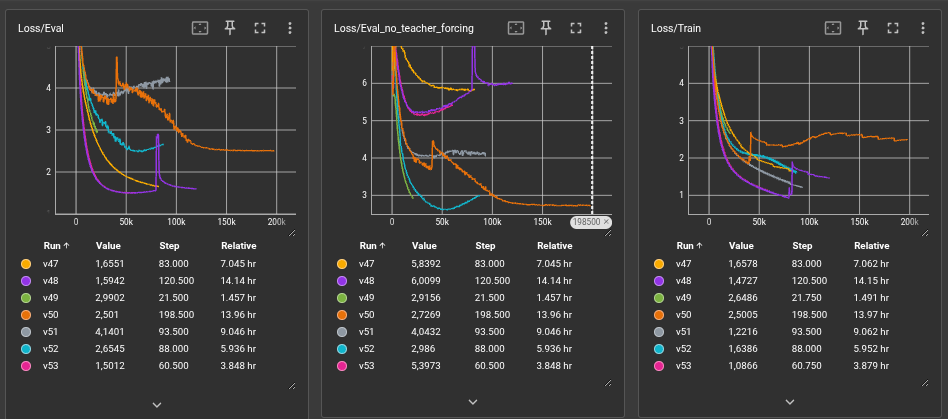

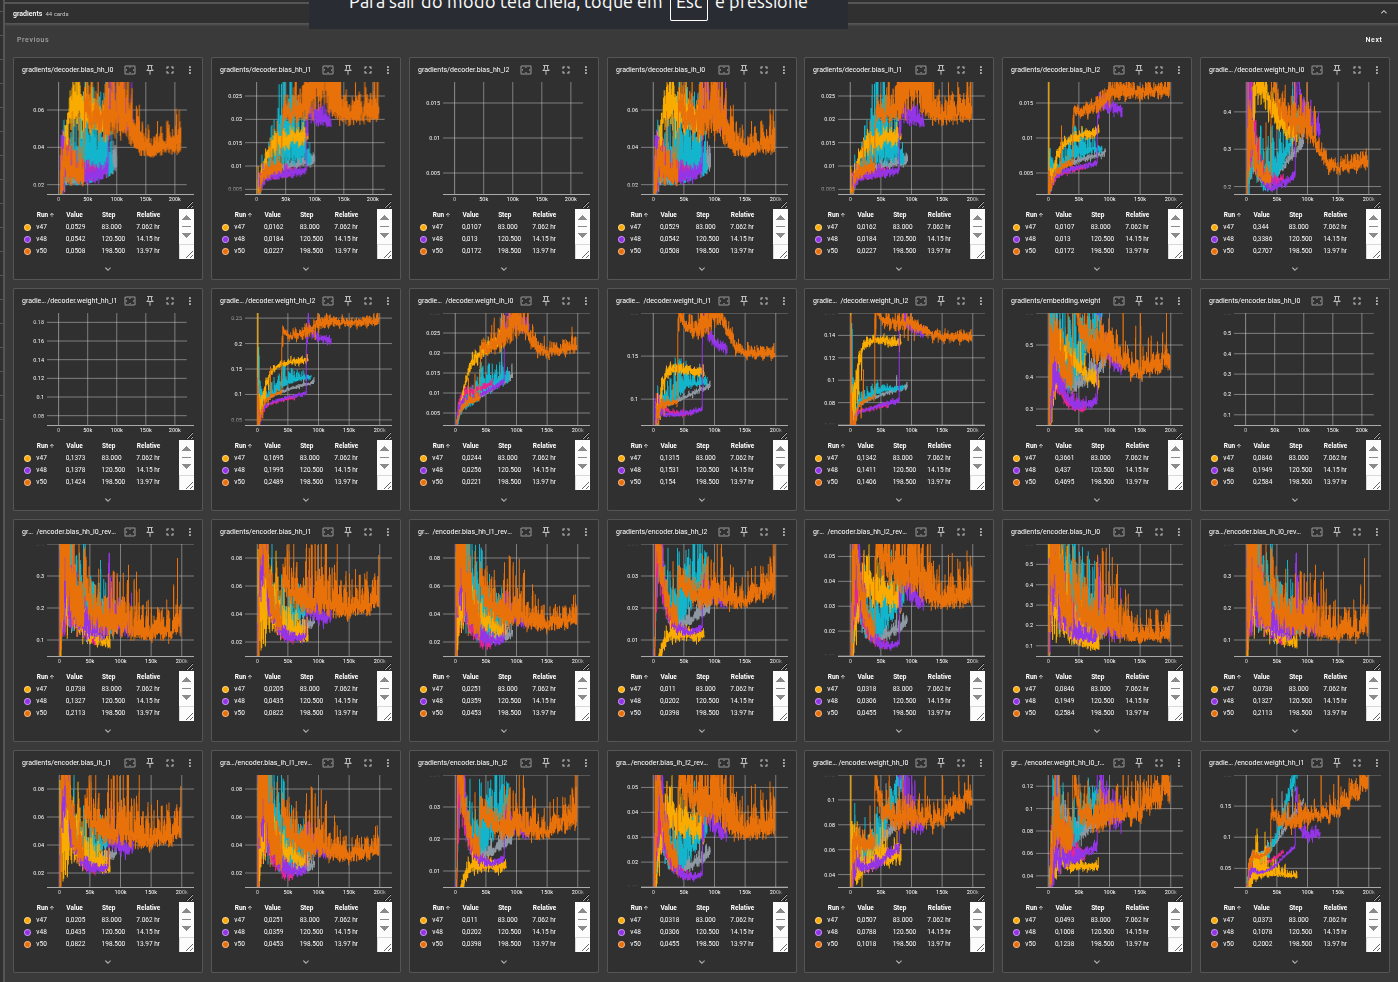

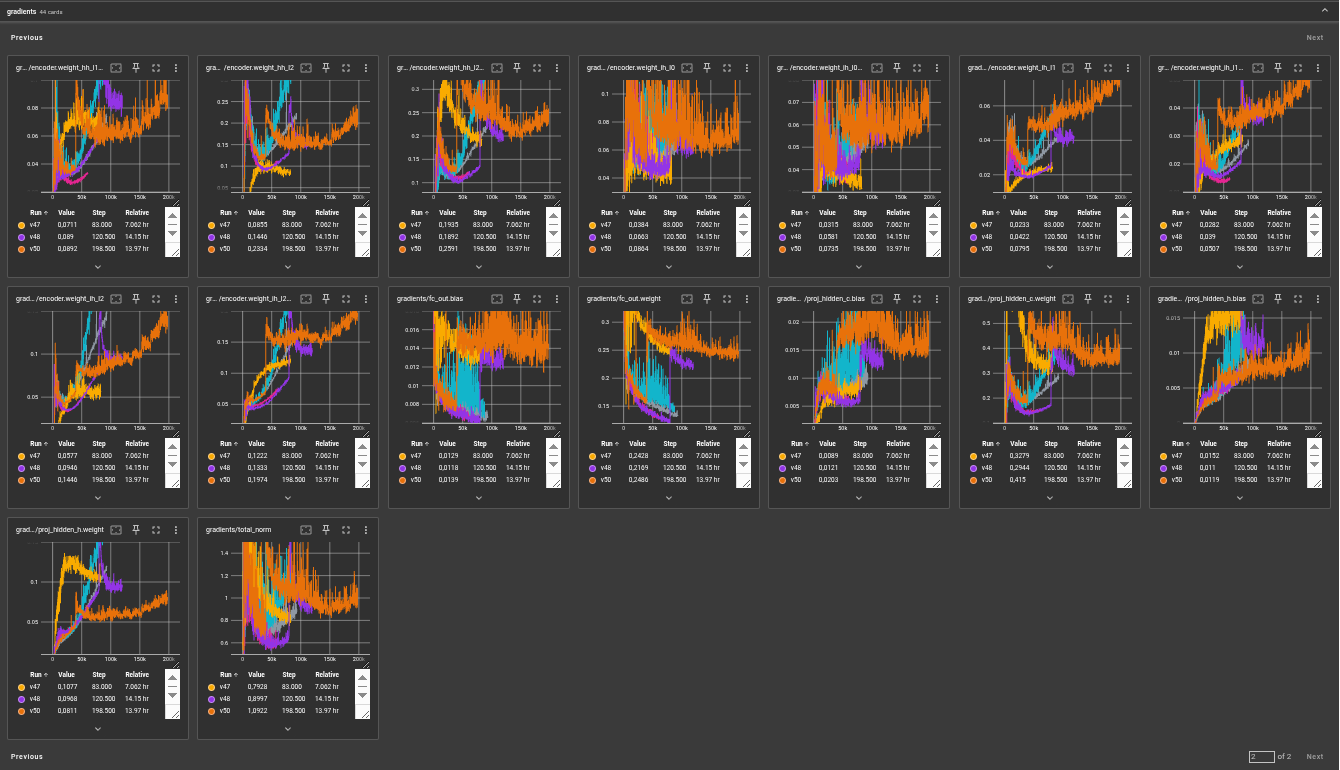

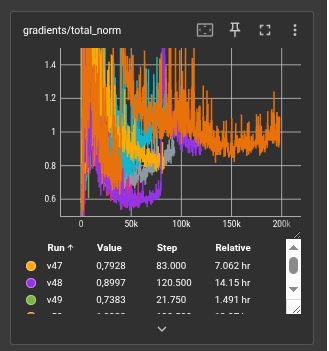

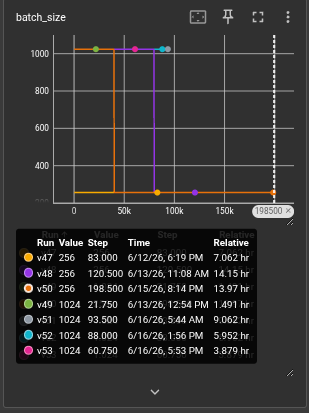

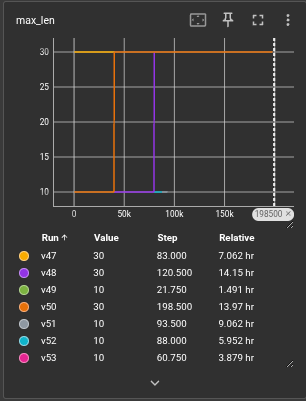

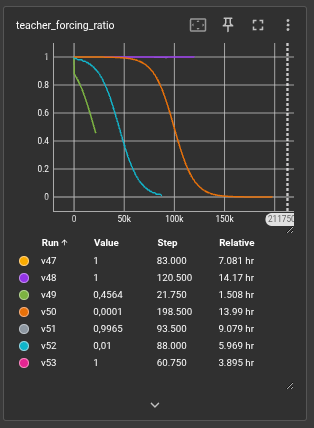

In [ ]:
for index in np.random.choice(len(df_eval), size=100, replace=False):
    print('Inglês:', df_eval['en'].iloc[index])
    print('Português:', df_eval['pt'].iloc[index])
    for column in df_eval.columns:
        if('_pred' in column):
            model_test = column
            print(f'{model_test}:', df_eval[model_test].iloc[index])
    print('-'*200)

Inglês: "hi, i'm on a skateboard.
Português: "olá, estou no skateboard.
v47_pred: " olá , tenho um carro de gasolina ". . . . . . . . .
v48_pred: " oi , de " cricket ". . . . .
v49_pred: " em .
v50_pred: " oi , estou num skate skate
v51_pred: " " in ). ). ". ".
v52_pred: " oi no .
v53_pred: " oi de " srta ". . . .
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: We won't go far i'll be careful, i promise.
Português: Não vamos longe. serei cuidadoso, prometo.
v47_pred: Não há tempo para eu ... vou dar um jeito , me desculpe . . . . . . . .
v48_pred: Vamos ser tolerados . . . . ! !
v49_pred: Não voltarei .
v50_pred: Não iremos longe , , terei cuidado , prometo .
v51_pred: Vamos . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
v52_pred: Não vou a .
v53_pred: Seremos felizes . . . . . . . . . . . . . .
---------------------